In [69]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from classes import Problem, Boat, Trip
import seaborn as sns

In [70]:
records = []
with open("original_mip_output.txt", "r") as f:
    for line in f:
        if line.strip():
            d = ast.literal_eval(line.strip())
            # d = eval(line.strip())
            d['solution_log'] = str(d['solution_log'])
            records.append(d)

# --- Step 2: Build DataFrame ---
df_mip_final = pd.DataFrame(records)
df_mip_final["bound_gap"] = (df_mip_final["best_obj"]-df_mip_final["best_bound"])/df_mip_final["best_bound"]*100

In [71]:
df = df_mip_final.copy()
df = df[df['num_stations'] < 500]
for col in ['best_obj', 'best_bound', 'runtime']:
    df[col] = df[col].round(2)
for col in ['num_continuous_vars', 'num_integer_vars', 'num_binary_vars']:
    df[col] = df[col].astype(int)
df = df.reindex(columns=['problem_id', 'num_stations',
       'percentage_kept', 'num_dummy_ports',
       'num_continuous_vars', 'num_integer_vars', 'num_binary_vars',
       'num_constraints', 'best_obj',
       'best_bound', 'bound_gap', 'runtime'])
for col in ['best_obj', 'best_bound', 'bound_gap', 'runtime']:
    df[col] = df[col].round(2)
header = ['Problem ID', '\\# Station-Pairs', '\\% Kept', '\\# Dummy Ports',
                '\\# Continuous Vars', '# Integer Vars', '\\# Binary Vars', '\\# Constraints', 
                'Best Objective', 'Best Bound', 'Bound Gap (\%)', 'Runtime (s)']
latex = df.to_latex(#buf='orig_mip_latex.txt', 
    columns=['problem_id', 'num_stations',
       'percentage_kept', 'num_dummy_ports',
       'num_continuous_vars', 'num_integer_vars', 'num_binary_vars',
       'num_constraints', 'best_obj',
       'best_bound', 'bound_gap', 'runtime'],
       header=header,
                float_format="%.2f",
                index=False)
latex = latex.replace('\\\\', '\\\\ \\hline')
latex = latex.replace('NaN', 'None')
for head in header:
    latex = latex.replace(head, '\\textbf{' + head + '}')

with open('orig_mip_latex.txt', 'w') as f:
    f.write(str(latex) + '\n')

<>:16: SyntaxWarning: invalid escape sequence '\%'
<>:16: SyntaxWarning: invalid escape sequence '\%'
C:\Users\saahi\AppData\Local\Temp\ipykernel_6980\1741408088.py:16: SyntaxWarning: invalid escape sequence '\%'
  'Best Objective', 'Best Bound', 'Bound Gap (\%)', 'Runtime (s)']


In [72]:
records = []
with open("final_mip_output.txt", "r") as f:
    for line in f:
        if line.strip():
            d = ast.literal_eval(line.strip())
            # d = eval(line.strip())
            records.append(d)

# --- Step 2: Build DataFrame ---
df_mip_final = pd.DataFrame(records)
df_mip_final["bound_gap"] = (df_mip_final["best_obj"]-df_mip_final["best_bound"])/df_mip_final["best_bound"]*100

In [73]:
df = df_mip_final.copy()
df = df[df['num_stations'] < 500]
for col in ['best_obj', 'best_bound', 'runtime']:
    df[col] = df[col].round(2)
for col in ['num_continuous_vars', 'num_integer_vars', 'num_binary_vars']:
    df[col] = df[col].astype(int)
df = df.reindex(columns=['problem_id', 'num_stations',
       'percentage_kept', 'num_dummy_ports',
       'num_continuous_vars', 'num_integer_vars', 'num_binary_vars',
       'num_constraints', 'best_obj',
       'best_bound', 'bound_gap', 'runtime'])
for col in ['best_obj', 'best_bound', 'bound_gap', 'runtime']:
    df[col] = df[col].round(2)
header = ['Problem ID', '\\# Station-Pairs', 'Best Objective', 'Best Bound', 'Bound Gap (\%)']
latex = df.to_latex(#buf='orig_mip_latex.txt', 
    columns=['problem_id', 'num_stations', 'best_obj',
       'best_bound', 'bound_gap'],
       header=header,
                float_format="%.2f",
                index=False)
latex = latex.replace('\\\\', '\\\\ \\hline')
latex = latex.replace('NaN', 'None')
latex = latex.replace('_', '\_')
for head in header:
    latex = latex.replace(head, '\\textbf{' + head + '}')

with open('final_mip_latex.txt', 'w') as f:
    f.write(str(latex) + '\n')

<>:14: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\_'
<>:14: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\_'
C:\Users\saahi\AppData\Local\Temp\ipykernel_6980\2965634090.py:14: SyntaxWarning: invalid escape sequence '\%'
  header = ['Problem ID', '\\# Station-Pairs', 'Best Objective', 'Best Bound', 'Bound Gap (\%)']
C:\Users\saahi\AppData\Local\Temp\ipykernel_6980\2965634090.py:23: SyntaxWarning: invalid escape sequence '\_'
  latex = latex.replace('_', '\_')


In [74]:
records = []
with open("initial_heur_output.txt", "r") as f:
    for line in f:
        if line.strip():
            d = ast.literal_eval(line.strip())
            # d = eval(line.strip())
            d['solution_log'] = str(d['solution_log'])
            records.append(d)

# --- Step 2: Build DataFrame ---
df_heur_orig = pd.DataFrame(records)

In [75]:
df = df_heur_orig.copy()
df['num_stations'] = df['num_stations']//2
df['method'] = df['method'].map({1: "NDS", 2: "NDM", 3: "SDM", 4: "NDC", 5: "SDS", 6: "TSM", 7: "TSS", 8: "SA", 9: "TSC", 10: "ACO", 11:"SDC"})
df['method'] = df['method'].map({'NDS': 2, 'NDM': 1, 'SDM':4, 'NDC': 3, 'SDS': 5, 'TSM': 7, 'TSS': 8, 'SA': 10, 'TSC': 9, 'ACO': 11, 'SDC': 6})
df = df.sort_values(['method', 'problem_id'], ascending=[True, False])
df['method'] = df['method'].map({2: 'NDS', 1: 'NDM', 4: 'SDM', 3: 'NDC', 5: 'SDS', 7: 'TSM', 8: 'TSS', 10: 'SA', 9: 'TSC', 11: 'ACO', 6: 'SDC'})

# df = df[df['num_stations'] < 500]
for col in ['best_obj']:
    df[col] = df[col].round(2)
df = df.reindex(columns=['problem_id', 'num_stations', 'method', 'num_iter', 'best_obj'])
for col in ['best_obj']:
    df[col] = df[col].round(2)
header = ['Problem ID', '\\# Station-Pairs', 'Algorithm', '\# Iterations', 'Best Objective']
latex = df.to_latex(#buf='orig_mip_latex.txt', 
    columns=['problem_id', 'num_stations', 'method', 'num_iter', 'best_obj'],
       header=header,
                float_format="%.2f",
                index=False)
latex = latex.replace('\\\\', '\\\\ \\hline')
latex = latex.replace('NaN', 'None')
latex = latex.replace('_', '\_')
for head in header:
    latex = latex.replace(head, '\\textbf{' + head + '}')

with open('initial_heur_latex.txt', 'w') as f:
    f.write(str(latex) + '\n')

<>:14: SyntaxWarning: invalid escape sequence '\#'
<>:22: SyntaxWarning: invalid escape sequence '\_'
<>:14: SyntaxWarning: invalid escape sequence '\#'
<>:22: SyntaxWarning: invalid escape sequence '\_'
C:\Users\saahi\AppData\Local\Temp\ipykernel_6980\2943565201.py:14: SyntaxWarning: invalid escape sequence '\#'
  header = ['Problem ID', '\\# Station-Pairs', 'Algorithm', '\# Iterations', 'Best Objective']
C:\Users\saahi\AppData\Local\Temp\ipykernel_6980\2943565201.py:22: SyntaxWarning: invalid escape sequence '\_'
  latex = latex.replace('_', '\_')


In [76]:
records = []
with open("final_heur_output.txt", "r") as f:
    for line in f:
        if line.strip():
            d = ast.literal_eval(line.strip())
            # d = eval(line.strip())
            d['solution_log'] = str(d['solution_log'])
            records.append(d)

# --- Step 2: Build DataFrame ---
df_huer_final_orig = pd.DataFrame(records)
# display(df_huer_final_orig)

In [77]:
df = df_huer_final_orig.copy()
df['num_stations'] = df['num_stations']//2
df['method'] = df['method'].map({1: "NDS", 2: "NDM", 3: "SDM", 4: "NDC", 5: "SDS", 6: "TSM", 7: "TSS", 8: "SA", 9: "TSC", 10: "ACO", 11:"SDC"})
df['method'] = df['method'].map({'NDS': 2, 'NDM': 1, 'SDM':4, 'NDC': 3, 'SDS': 5, 'TSM': 7, 'TSS': 8, 'SA': 10, 'TSC': 9, 'ACO': 11, 'SDC': 6})
df = df.sort_values(['method', 'problem_id'], ascending=[True, False])
df['method'] = df['method'].map({2: 'NDS', 1: 'NDM', 4: 'SDM', 3: 'NDC', 5: 'SDS', 7: 'TSM', 8: 'TSS', 10: 'SA', 9: 'TSC', 11: 'ACO', 6: 'SDC'})

# df = df[df['num_stations'] < 500]
for col in ['best_obj']:
    df[col] = df[col].round(2)
df = df.reindex(columns=['problem_id', 'num_stations', 'method', 'num_iter', 'best_obj'])
for col in ['best_obj']:
    df[col] = df[col].round(2)
header = ['Problem ID', '\\# Station-Pairs', 'Algorithm', '\# Iterations', 'Best Objective']
latex = df.to_latex(#buf='orig_mip_latex.txt', 
    columns=['problem_id', 'num_stations', 'method', 'num_iter', 'best_obj'],
       header=header,
                float_format="%.2f",
                index=False)
latex = latex.replace('\\\\', '\\\\ \\hline')
latex = latex.replace('NaN', 'None')
latex = latex.replace('_', '\_')
for head in header:
    latex = latex.replace(head, '\\textbf{' + head + '}')

with open('final_heur_latex.txt', 'w') as f:
    f.write(str(latex) + '\n')

<>:14: SyntaxWarning: invalid escape sequence '\#'
<>:22: SyntaxWarning: invalid escape sequence '\_'
<>:14: SyntaxWarning: invalid escape sequence '\#'
<>:22: SyntaxWarning: invalid escape sequence '\_'
C:\Users\saahi\AppData\Local\Temp\ipykernel_6980\1351211722.py:14: SyntaxWarning: invalid escape sequence '\#'
  header = ['Problem ID', '\\# Station-Pairs', 'Algorithm', '\# Iterations', 'Best Objective']
C:\Users\saahi\AppData\Local\Temp\ipykernel_6980\1351211722.py:22: SyntaxWarning: invalid escape sequence '\_'
  latex = latex.replace('_', '\_')


In [232]:
import glob
import numpy as np
prob_id = 0
all_df = pd.DataFrame()
for prob_id in range(36):
    filename = glob.glob(f"better_test_problems/test_problem{prob_id:02d}*")[0]
    with open(filename, "r") as f:
        result = f.read()
    split = result.split('; ')
    s = np.array(eval(split[0]))
    p = np.array(eval(split[1]))
    b = int(split[2])
    c = np.array(eval(split[3]))
    t = int(split[4])
    w = int(split[5])
    u = int(split[6])
    cap_string = ''
    for cap in c:
        cap_string += str(cap) + ', '
    cap_string = cap_string[:-2]
    if len(s) > 100:
          region = 'A'
    elif len(s) > 20 and len(p) == 2:
          region = 'B'
    elif len(s) > 20 and len(p) == 1:
          region = 'C'
    elif len(p) == 2:
          region = 'D'
    else:
          region = 'E'
    dict = {'problem_id': prob_id, 'region': region, 'num_stations': len(s), 'num_ports': len(p), 'num_boats': b, 
            'capacities': cap_string, 'time_limit': t, 'station_limit': w, 'upper_bound': u}
    # df = pd.DataFrame(dict)
    df = pd.DataFrame.from_dict({0: dict}, orient='index')
    all_df = pd.concat([all_df,df])

header = ['Problem ID', 'Region', '\\# Station-Pairs', '\\# Ports', '\# Boats', 
          'Capacities', 'Carrying Time Limit', 'Station Limit', 'Upper Bound']
latex = all_df.to_latex(#buf='orig_mip_latex.txt', 
    columns=['problem_id', 'region', 'num_stations', 'num_ports', 'num_boats', 'capacities', 
            'time_limit', 'station_limit', 'upper_bound'],
       header=header,
                float_format="%.2f",
                index=False)
latex = latex.replace('\\\\', '\\\\ \\hline')
latex = latex.replace('NaN', 'None')
latex = latex.replace('_', '\_')
for head in header:
    latex = latex.replace(head, '\\textbf{' + head + '}')

with open('initial_probs_latex.txt', 'w') as f:
    f.write(str(latex) + '\n')

<>:37: SyntaxWarning: invalid escape sequence '\#'
<>:47: SyntaxWarning: invalid escape sequence '\_'
<>:37: SyntaxWarning: invalid escape sequence '\#'
<>:47: SyntaxWarning: invalid escape sequence '\_'
C:\Users\saahi\AppData\Local\Temp\ipykernel_6980\1620162799.py:37: SyntaxWarning: invalid escape sequence '\#'
  header = ['Problem ID', 'Region', '\\# Station-Pairs', '\\# Ports', '\# Boats',
C:\Users\saahi\AppData\Local\Temp\ipykernel_6980\1620162799.py:47: SyntaxWarning: invalid escape sequence '\_'
  latex = latex.replace('_', '\_')


In [245]:
import glob
import numpy as np
prob_id = 0
all_df = pd.DataFrame()
probs = [6, 12, 24, 34]
problems = []
for prob in probs:
     for i in range(10):
        problems.append(f'{prob:02d}' + f'_{str(i)}')
print(problems)
for prob_id in problems:
    filename = glob.glob(f"final_test_problems/test_problem{prob_id}*")[0]
    with open(filename, "r") as f:
        result = f.read()
    split = result.split('; ')
    s = np.array(eval(split[0]))
    p = np.array(eval(split[1]))
    b = int(split[2])
    c = np.array(eval(split[3]))
    t = int(split[4])
    w = int(split[5])
    u = int(split[6])

    cap_string = ''
    for cap in c:
        cap_string += str(cap) + ', '
    cap_string = cap_string[:-2]
    if len(s) > 100:
          region = 'A'
    elif len(s) > 20 and len(p) == 2:
          region = 'B'
    elif len(s) > 20 and len(p) == 1:
          region = 'C'
    elif len(p) == 2:
          region = 'D'
    else:
          region = 'E'
    dict = {'problem_id': prob_id, 'region': region, 'num_stations': len(s), 'num_ports': len(p), 'num_boats': b, 
            'capacities': cap_string, 'time_limit': t, 'station_limit': w, 'upper_bound': u}
    # df = pd.DataFrame(dict)
    df = pd.DataFrame.from_dict({0: dict}, orient='index')
    all_df = pd.concat([all_df,df])

header = ['Problem ID', 'Region', '\\# Station-Pairs', '\\# Ports', '\# Boats', 
          'Capacities', 'Carrying Time Limit', 'Station Limit', 'Upper Bound']
latex = all_df.to_latex(#buf='orig_mip_latex.txt', 
    columns=['problem_id', 'region', 'num_stations', 'num_ports', 'num_boats', 'capacities', 
            'time_limit', 'station_limit', 'upper_bound'],
       header=header,
                float_format="%.2f",
                index=False)
latex = latex.replace('\\\\', '\\\\ \\hline')
latex = latex.replace('NaN', 'None')
latex = latex.replace('_', '\_')
for head in header:
    latex = latex.replace(head, '\\textbf{' + head + '}')

with open('final_probs_latex.txt', 'w') as f:
    f.write(str(latex) + '\n')

<>:44: SyntaxWarning: invalid escape sequence '\#'
<>:54: SyntaxWarning: invalid escape sequence '\_'
<>:44: SyntaxWarning: invalid escape sequence '\#'
<>:54: SyntaxWarning: invalid escape sequence '\_'
C:\Users\saahi\AppData\Local\Temp\ipykernel_6980\2546462269.py:44: SyntaxWarning: invalid escape sequence '\#'
  header = ['Problem ID', 'Region', '\\# Station-Pairs', '\\# Ports', '\# Boats',
C:\Users\saahi\AppData\Local\Temp\ipykernel_6980\2546462269.py:54: SyntaxWarning: invalid escape sequence '\_'
  latex = latex.replace('_', '\_')


['06_0', '06_1', '06_2', '06_3', '06_4', '06_5', '06_6', '06_7', '06_8', '06_9', '12_0', '12_1', '12_2', '12_3', '12_4', '12_5', '12_6', '12_7', '12_8', '12_9', '24_0', '24_1', '24_2', '24_3', '24_4', '24_5', '24_6', '24_7', '24_8', '24_9', '34_0', '34_1', '34_2', '34_3', '34_4', '34_5', '34_6', '34_7', '34_8', '34_9']


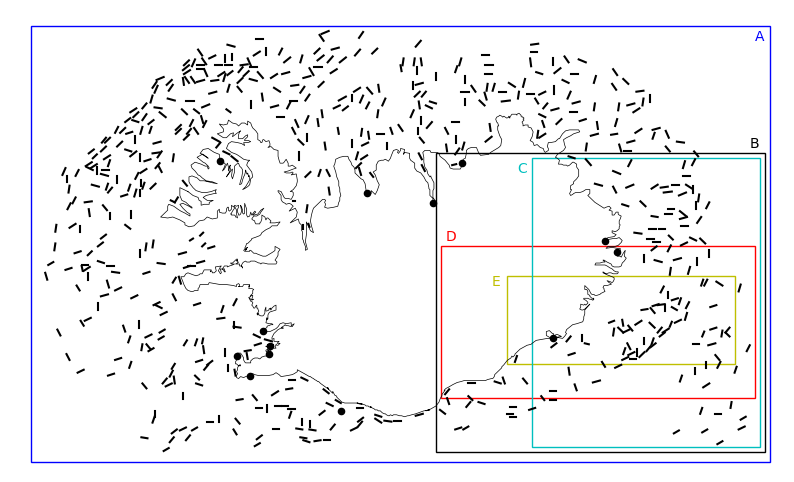

In [228]:
import glob
import numpy as np
from classes import *
import matplotlib.patches as patches

problem_id = -1
if problem_id == -1:
    port_idx = np.arange(13)
    stations_ids = np.arange(581)
else:
    port_idx, stations_ids, _ = load_test_problem(problem_id)

# port_idx, stations_ids1, _ = load_test_problem(5)
# port_idx, stations_ids2, _ = load_test_problem(2)
# stations_ids = np.array(list(set(stations_ids1).union(set(stations_ids2))))
# port_idx = [11, 12]
stations_idx = np.stack([stations_ids * 2, stations_ids * 2 + 1]).T.reshape(-1) + 13

Prob = Problem(stations_idx, port_idx, 10, 1, [0], [0])

island_data = load_island_data()
nodes, total_ports, total_stations = load_nodes()

fig,ax = plt.subplots(figsize=(10,6)) # figsize=(15,13)
ax.plot(*degArr2point(island_data), color="k", linewidth=0.5)
# plot ports
for idx in port_idx:
    ax.scatter(*degArr2point(nodes[[idx]]), s=20, c='k')

# plot stations
for i in range(0, len(stations_idx), 2):
    station = nodes[[stations_idx[i], stations_idx[i]+1], :]
    ax.plot(*degArr2point(station), 'k')
    # if annotate:
    #     ax.annotate(int(math.floor((stations_idx[i]-13)/2)), degArr2point(station[[0], :]).flatten())
        
# plt.gca().invert_yaxis()
ax.invert_yaxis()

# 4: rect = patches.Rectangle((5, -5), 320, 140, linewidth=1, edgecolor='r', facecolor='none')
# 25: rect = patches.Rectangle((0, -110), 315, 295, linewidth=1, edgecolor='r', facecolor='none')
# 6: rect = patches.Rectangle((70, 10), 225, 90, linewidth=1, edgecolor='r', facecolor='none')
# 5: rect = patches.Rectangle((95, -110), 220, 295, linewidth=1, edgecolor='r', facecolor='none')
rect1 = patches.Rectangle((5, -20), 310, 155, linewidth=1, edgecolor='r', facecolor='none')
rect2 = patches.Rectangle((0, -115), 325, 305, linewidth=1, edgecolor='k', facecolor='none')
rect3 = patches.Rectangle((70, 10), 225, 90, linewidth=1, edgecolor='y', facecolor='none')
rect4 = patches.Rectangle((95, -110), 225, 295, linewidth=1, edgecolor='c', facecolor='none')
rect5 = patches.Rectangle((-400, -245), 730, 445, linewidth=1, edgecolor='b', facecolor='none')
ax.add_patch(rect1)
ax.add_patch(rect2)
ax.add_patch(rect3)
ax.add_patch(rect4)
ax.add_patch(rect5)
ax.text(315, -230, 'A', color='b')
ax.text(310, -120, 'B', color='k')
ax.text(80, -95, 'C', color='c')
ax.text(10, -25, 'D', color='r')
ax.text(55, 20, 'E', color='y')
ax.set_axis_off()

(np.float64(1550.6941894130032), np.float64(0.0))


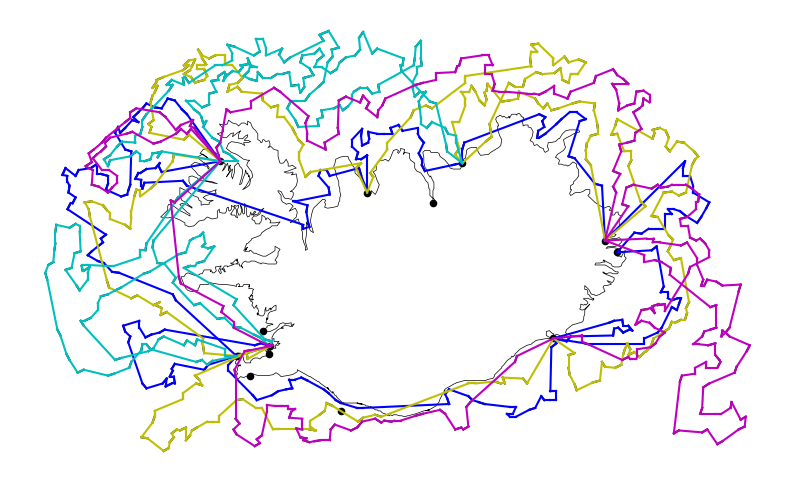

In [249]:
import glob
import numpy as np
from classes import *
import matplotlib.patches as patches

problem_id = -1
if problem_id == -1:
    port_idx = np.arange(13)
    stations_ids = np.arange(581)
else:
    port_idx, stations_ids, _ = load_test_problem(problem_id)

# port_idx, stations_ids1, _ = load_test_problem(5)
# port_idx, stations_ids2, _ = load_test_problem(2)
# stations_ids = np.array(list(set(stations_ids1).union(set(stations_ids2))))
# port_idx = [11, 12]
stations_idx = np.stack([stations_ids * 2, stations_ids * 2 + 1]).T.reshape(-1) + 13

Prob = Problem(stations_idx, port_idx, 100, 4, [15000, 45000, 200000, 200000], [4, 4, 4, 4])
sol = [[[4, 313, 314, 334, 333, 332, 331, 344, 343, 346, 345, 348, 347, 215, 216, 206, 205, 213, 214, 211, 212, 208, 207, 210, 209, 196, 195, 2], [2, 190, 189, 187, 188, 185, 186, 183, 184, 177, 178, 175, 176, 173, 174, 169, 170, 56, 55, 165, 166, 160, 159, 164, 163, 155, 156, 157, 158, 35, 36, 33, 34, 31, 32, 145, 146, 143, 144, 148, 147, 300, 299, 12], [12, 298, 297, 284, 283, 270, 269, 280, 279, 271, 272, 273, 274, 281, 282, 12], [12, 291, 292, 286, 285, 248, 247, 374, 373, 385, 386, 387, 388, 383, 384, 381, 382, 468, 467, 11], [11, 478, 477, 457, 458, 459, 460, 547, 548, 552, 551, 549, 550, 441, 442, 531, 532, 537, 538, 554, 553, 669, 670, 10], [10, 572, 571, 690, 689, 687, 688, 878, 877, 702, 701, 703, 704, 700, 699, 697, 698, 905, 906, 719, 720, 9], [9, 722, 721, 573, 574, 731, 732, 723, 724, 727, 728, 733, 734, 742, 741, 750, 749, 737, 738, 739, 740, 735, 736, 758, 757, 752, 751, 743, 744, 7], [7, 575, 576, 581, 582, 583, 584, 580, 579, 590, 589, 587, 588, 482, 481, 479, 480, 591, 592, 602, 601, 593, 594, 621, 622, 595, 596, 807, 808, 598, 597, 6], [6, 1062, 1061, 1088, 1087, 1081, 1082, 1080, 1079, 1092, 1091, 831, 832, 827, 828, 834, 833, 848, 847, 616, 615, 613, 614, 610, 609, 625, 626, 637, 638, 849, 850, 652, 651, 644, 643, 650, 649, 646, 645, 633, 634, 647, 648, 509, 510, 513, 514, 525, 526, 506, 505, 422, 421, 408, 407, 2], [2, 4]], [[4, 317, 318, 201, 202, 200, 199, 204, 203, 109, 110, 115, 116, 117, 118, 111, 112, 119, 120, 114, 113, 105, 106, 103, 104, 107, 108, 99, 100, 101, 102, 191, 192, 89, 90, 83, 84, 68, 67, 70, 69, 61, 62, 171, 172, 51, 52, 53, 54, 167, 168, 154, 153, 152, 151, 149, 150, 12], [12, 295, 296, 139, 140, 137, 138, 135, 136, 141, 142, 133, 134, 289, 290, 268, 267, 276, 275, 261, 262, 242, 241, 258, 257, 249, 250, 255, 256, 251, 252, 259, 260, 372, 371, 469, 470, 454, 453, 466, 465, 545, 546, 542, 541, 560, 559, 656, 655, 658, 657, 660, 659, 667, 668, 662, 661, 663, 664, 665, 666, 684, 683, 682, 681, 672, 671, 677, 678, 565, 566, 10], [10, 694, 693, 691, 692, 695, 696, 685, 686, 879, 880, 876, 875, 899, 900, 902, 901, 896, 895, 922, 921, 928, 927, 910, 909, 919, 920, 924, 923, 937, 938, 936, 935, 929, 930, 714, 713, 710, 709, 9], [9, 707, 708, 705, 706, 915, 916, 897, 898, 908, 907, 891, 892, 884, 883, 887, 888, 1093, 1094, 1096, 1095, 1099, 1100, 1103, 1104, 1098, 1097, 1102, 1101, 934, 933, 957, 958, 952, 951, 746, 745, 578, 577, 7], [7, 747, 748, 585, 586, 774, 773, 772, 771, 768, 767, 765, 766, 1002, 1001, 1032, 1031, 1025, 1026, 1033, 1034, 1027, 1028, 1144, 1143, 1146, 1145, 1161, 1162, 1173, 1174, 1164, 1163, 1166, 1165, 1040, 1039, 1042, 1041, 1053, 1054, 1051, 1052, 1063, 1064, 1168, 1167, 1170, 1169, 1038, 1037, 1086, 1085, 1070, 1069, 1078, 1077, 1071, 1072, 798, 797, 810, 809, 779, 780, 6], [6, 804, 803, 604, 603, 599, 600, 617, 618, 630, 629, 512, 511, 627, 628, 631, 632, 653, 654, 642, 641, 424, 423, 428, 427, 409, 410, 413, 414, 403, 404, 322, 321, 319, 320, 2], [2, 4]], [[4, 303, 304, 396, 395, 399, 400, 486, 485, 484, 483, 488, 487, 493, 494, 492, 491, 490, 489, 495, 496, 405, 406, 419, 420, 418, 417, 426, 425, 355, 356, 357, 358, 349, 350, 336, 335, 342, 341, 329, 330, 327, 328, 310, 309, 2], [2, 197, 198, 325, 326, 339, 340, 337, 338, 218, 217, 220, 219, 221, 222, 352, 351, 354, 353, 440, 439, 530, 529, 523, 524, 527, 528, 515, 516, 520, 519, 521, 522, 437, 438, 429, 430, 435, 436, 433, 434, 431, 432, 518, 517, 508, 507, 504, 503, 502, 501, 605, 606, 6], [6, 777, 778, 775, 776, 793, 794, 788, 787, 781, 782, 1060, 1059, 1065, 1066, 1067, 1068, 1056, 1055, 1046, 1045, 1043, 1044, 1050, 1049, 1020, 1019, 1021, 1022, 1153, 1154, 1155, 1156, 1015, 1016, 1017, 1018, 1023, 1024, 1014, 1013, 1009, 1010, 1005, 1006, 999, 1000, 997, 998, 995, 996, 985, 986, 1139, 1140, 1126, 1125, 1127, 1128, 981, 982, 983, 984, 1132, 1131, 1120, 1119, 1118, 1117, 1122, 1121, 1112, 1111, 960, 959, 946, 945, 715, 716, 9], [9, 717, 718, 711, 712, 729, 730, 725, 726, 949, 950, 953, 954, 948, 947, 955, 956, 944, 943, 1116, 1115, 1114, 1113, 1109, 1110, 972, 971, 961, 962, 974, 973, 978, 977, 976, 975, 988, 987, 992, 991, 756, 755, 763, 764, 1003, 1004, 993, 994, 1011, 1012, 979, 980, 1135, 1136, 1133, 1134, 1129, 1130, 1124, 1123, 1137, 1138, 1141, 1142, 1149, 1150, 1157, 1158, 1152, 1151, 1159, 1160, 1148, 1147, 1172, 1171, 1057, 1058, 1047, 1048, 1074, 1073, 1075, 1076, 795, 796, 816, 815, 846, 845, 843, 844, 829, 830, 824, 823, 838, 837, 806, 805, 820, 819, 812, 811, 814, 813, 6], [6, 6], [6, 497, 498, 500, 499, 411, 412, 401, 402, 323, 324, 305, 306, 316, 315, 4]], [[4, 312, 311, 193, 194, 97, 98, 95, 96, 93, 94, 91, 92, 87, 88, 180, 179, 182, 181, 85, 86, 80, 79, 77, 78, 81, 82, 73, 74, 75, 76, 65, 66, 63, 64, 72, 71, 60, 59, 58, 57, 47, 48, 49, 50, 45, 46, 44, 43, 39, 40, 37, 38, 41, 42, 162, 161, 302, 301, 12], [12, 293, 294, 287, 288, 263, 264, 266, 265, 245, 246, 253, 254, 244, 243, 278, 277, 393, 394, 389, 390, 380, 379, 378, 377, 376, 375, 370, 369, 448, 447, 444, 443, 446, 445, 451, 452, 474, 473, 533, 534, 536, 535, 540, 539, 556, 555, 543, 544, 557, 558, 567, 568, 563, 564, 10], [10, 462, 461, 463, 464, 472, 471, 449, 450, 361, 362, 364, 363, 367, 368, 359, 360, 230, 229, 228, 227, 232, 231, 224, 223, 122, 121, 128, 127, 22, 21, 28, 27, 19, 20, 16, 15, 18, 17, 26, 25, 24, 23, 29, 30, 132, 131, 129, 130, 125, 126, 123, 124, 239, 240, 225, 226, 237, 238, 233, 234, 235, 236, 366, 365, 392, 391, 455, 456, 476, 475, 10], [10, 570, 569, 562, 561, 673, 674, 679, 680, 675, 676, 865, 866, 859, 860, 857, 858, 872, 871, 864, 863, 862, 861, 874, 873, 870, 869, 868, 867, 882, 881, 886, 885, 889, 890, 903, 904, 894, 893, 914, 913, 925, 926, 912, 911, 917, 918, 1106, 1105, 1108, 1107, 939, 940, 932, 931, 942, 941, 967, 968, 970, 969, 963, 964, 966, 965, 990, 989, 760, 759, 754, 753, 770, 769, 762, 761, 1007, 1008, 1030, 1029, 1036, 1035, 789, 790, 6], [6, 786, 785, 802, 801, 818, 817, 821, 822, 842, 841, 836, 835, 856, 855, 620, 619, 623, 624, 611, 612, 636, 635, 640, 639, 854, 853, 852, 851, 839, 840, 825, 826, 1089, 1090, 1083, 1084, 800, 799, 784, 783, 792, 791, 6], [6, 608, 607, 416, 415, 397, 398, 307, 308, 14, 13, 4]]]
Prob.restore_solution_from_list(sol)
print(Prob.evaluate_solution(0, 0, 0))

solution = []
for boat in Prob.boats:
    path = []
    for trip in boat.route:
        full_trip = trip.get_full_trip()
        for i in range(len(full_trip)-1):
            path.append((full_trip[i], full_trip[i+1]))
    solution.append(path)

island_data = load_island_data()
nodes, total_ports, total_stations = load_nodes()

fig,ax = plt.subplots(figsize=(10,6)) # figsize=(15,13)
ax.plot(*degArr2point(island_data), color="k", linewidth=0.5)
# plot ports
for idx in port_idx:
    ax.scatter(*degArr2point(nodes[[idx]]), s=20, c='k')

# plot stations
for i in range(0, len(stations_idx), 2):
    station = nodes[[stations_idx[i], stations_idx[i]+1], :]
    ax.plot(*degArr2point(station), 'k')
    # if annotate:
    #     ax.annotate(int(math.floor((stations_idx[i]-13)/2)), degArr2point(station[[0], :]).flatten())
colours = ['r-','b-','y-','c-','m-','g-','w-']
k=0

for path in solution:
    k += 1
    for i, j in path:
        ax.plot(*degArr2point(nodes[[i,j]]),  colours[k % 8], linewidth=1.5)
        
# plt.gca().invert_yaxis()
ax.invert_yaxis()
ax.axes.set_axis_off()